# Assignment 5 — Underfitting, Overfitting, Regularization & Dropout (CIFAR-10)
CSE4261/CSE4262 — Neural Network and Deep Learning

**Fix summary (vs. original draft):**
- Regularization / Dropout / Combined models now reuse the **exact same base architecture** as the Overfitting model (only the overfit model isolates the effect of each technique — otherwise you're comparing different architectures, not different techniques).
- A proper held-out **validation split** is carved out of the training set; the test set is only touched once, at final evaluation (previously the test set was reused as validation every epoch, which is leakage).
- Random seeds fixed for reproducibility.
- Added classification metrics (precision/recall/F1, confusion matrix) — "Performance metrics" was required by Part A/B/C/D, not just accuracy/loss curves.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================
# Load Dataset (CIFAR-10)
# ==============================
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# ==============================
# Proper train / validation split
# (test set is held out and ONLY used for final evaluation)
# ==============================
val_size = 5000
x_val, y_val = x_train_full[:val_size], y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:], y_train_full[val_size:]

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 383s 2us/step
Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [2]:
# ==============================
# Utility: Plot Graphs
# ==============================
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_and_report(model, name, model_names, accuracies, f1_scores):
    """Performance metrics on the held-out TEST set (never used during training)."""
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']

    print(f"\n{'='*60}\n{name} — Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    model_names.append(name)
    accuracies.append(acc)
    f1_scores.append(macro_f1)
    return loss, acc, macro_f1

Training UNDERFITTING model...
Epoch 1/10
704/704 - 5s - 7ms/step - accuracy: 0.4001 - loss: 1.7173 - val_accuracy: 0.4714 - val_loss: 1.5246
Epoch 2/10
704/704 - 2s - 3ms/step - accuracy: 0.4945 - loss: 1.4581 - val_accuracy: 0.5044 - val_loss: 1.4098
Epoch 3/10
704/704 - 2s - 3ms/step - accuracy: 0.5243 - loss: 1.3721 - val_accuracy: 0.5184 - val_loss: 1.3659
Epoch 4/10
704/704 - 3s - 4ms/step - accuracy: 0.5389 - loss: 1.3280 - val_accuracy: 0.5240 - val_loss: 1.3441
Epoch 5/10
704/704 - 5s - 7ms/step - accuracy: 0.5492 - loss: 1.2975 - val_accuracy: 0.5360 - val_loss: 1.3280
Epoch 6/10
704/704 - 2s - 3ms/step - accuracy: 0.5587 - loss: 1.2721 - val_accuracy: 0.5452 - val_loss: 1.3135
Epoch 7/10
704/704 - 2s - 3ms/step - accuracy: 0.5679 - loss: 1.2488 - val_accuracy: 0.5504 - val_loss: 1.3000
Epoch 8/10
704/704 - 3s - 5ms/step - accuracy: 0.5768 - loss: 1.2267 - val_accuracy: 0.5562 - val_loss: 1.2882
Epoch 9/10
704/704 - 2s - 3ms/step - accuracy: 0.5846 - loss: 1.2066 - val_accura

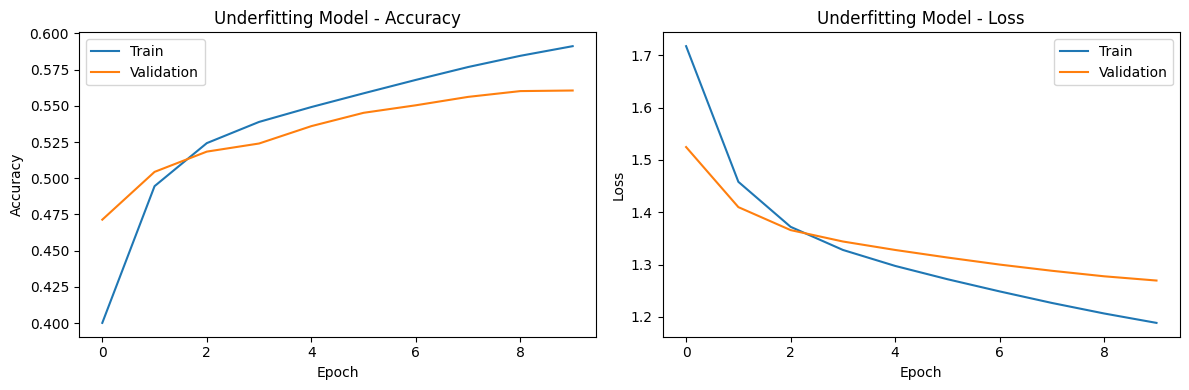

In [4]:
# ==============================
# PART A (1): Underfitting Model
# Deliberately too simple (single conv layer, few filters) AND trained briefly
# ==============================
def build_underfit_model():
    model = models.Sequential([
        layers.Conv2D(8, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    return model

underfit_model = build_underfit_model()
underfit_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

print("Training UNDERFITTING model...")
history_underfit = underfit_model.fit(
    x_train, y_train,
    epochs=10,   # deliberately very short + tiny capacity => underfitting
    validation_data=(x_val, y_val),
    batch_size=64,
    verbose=2
)

plot_history(history_underfit, "Underfitting Model")

Training OVERFITTING model (baseline architecture, no regularization, no dropout, long training)...
Epoch 1/30
704/704 - 15s - 21ms/step - accuracy: 0.4598 - loss: 1.4705 - val_accuracy: 0.5868 - val_loss: 1.1492
Epoch 2/30
704/704 - 6s - 9ms/step - accuracy: 0.6566 - loss: 0.9783 - val_accuracy: 0.6772 - val_loss: 0.9468
Epoch 3/30
704/704 - 7s - 9ms/step - accuracy: 0.7304 - loss: 0.7649 - val_accuracy: 0.7180 - val_loss: 0.8452
Epoch 4/30
704/704 - 6s - 9ms/step - accuracy: 0.7863 - loss: 0.6140 - val_accuracy: 0.7322 - val_loss: 0.8493
Epoch 5/30
704/704 - 7s - 9ms/step - accuracy: 0.8220 - loss: 0.5019 - val_accuracy: 0.7166 - val_loss: 0.9487
Epoch 6/30
704/704 - 6s - 9ms/step - accuracy: 0.8582 - loss: 0.3998 - val_accuracy: 0.7272 - val_loss: 0.9342
Epoch 7/30
704/704 - 7s - 9ms/step - accuracy: 0.8856 - loss: 0.3209 - val_accuracy: 0.7094 - val_loss: 1.1579
Epoch 8/30
704/704 - 6s - 9ms/step - accuracy: 0.9090 - loss: 0.2581 - val_accuracy: 0.7018 - val_loss: 1.2349
Epoch 9/30

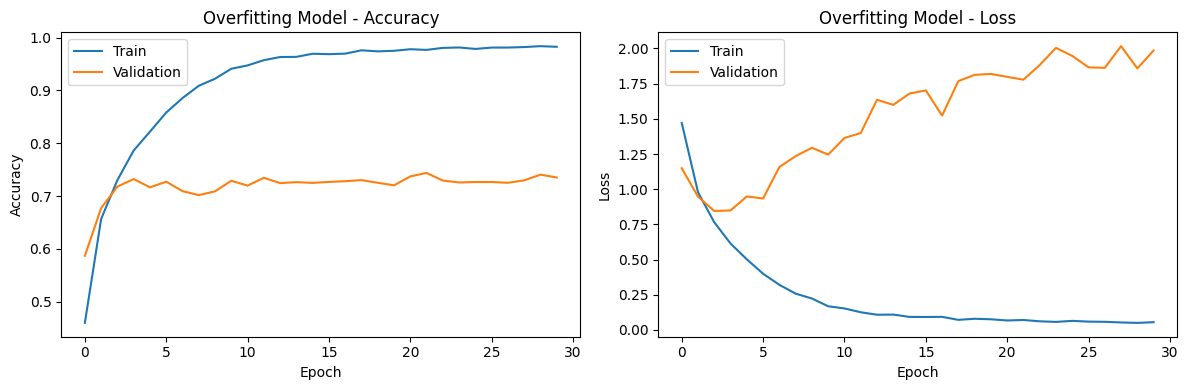

In [5]:
# ==============================
# PART A (2): Overfitting Model — this is the BASELINE architecture
# reused (unchanged) in Parts B, C, D so that regularization/dropout are the
# ONLY variable being tested against this baseline.
# ==============================
def build_base_cnn(use_l2=False, use_dropout=False, l2_lambda=1e-3, dropout_rates=(0.25, 0.25, 0.5)):
    reg = regularizers.l2(l2_lambda) if use_l2 else None

    layer_list = [
        layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=reg, input_shape=(32,32,3)),
        layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2,2),
    ]
    if use_dropout:
        layer_list.append(layers.Dropout(dropout_rates[0]))

    layer_list += [
        layers.Conv2D(128, (3,3), activation='relu', kernel_regularizer=reg),
        layers.Conv2D(128, (3,3), activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2,2),
    ]
    if use_dropout:
        layer_list.append(layers.Dropout(dropout_rates[1]))

    layer_list += [
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
    ]
    if use_dropout:
        layer_list.append(layers.Dropout(dropout_rates[2]))

    layer_list.append(layers.Dense(10, activation='softmax'))
    return models.Sequential(layer_list)

overfit_model = build_base_cnn(use_l2=False, use_dropout=False)
overfit_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("Training OVERFITTING model (baseline architecture, no regularization, no dropout, long training)...")
history_overfit = overfit_model.fit(
    x_train, y_train,
    epochs=30,   # prolonged training, no constraints => overfitting
    validation_data=(x_val, y_val),
    batch_size=64,
    verbose=2
)

plot_history(history_overfit, "Overfitting Model")

Training L2-REGULARIZED model (same architecture as overfit baseline)...
Epoch 1/30
704/704 - 15s - 22ms/step - accuracy: 0.4022 - loss: 1.8076 - val_accuracy: 0.5224 - val_loss: 1.4853
Epoch 2/30
704/704 - 7s - 9ms/step - accuracy: 0.5706 - loss: 1.3757 - val_accuracy: 0.6166 - val_loss: 1.2696
Epoch 3/30
704/704 - 7s - 10ms/step - accuracy: 0.6476 - loss: 1.2048 - val_accuracy: 0.6690 - val_loss: 1.1484
Epoch 4/30
704/704 - 7s - 9ms/step - accuracy: 0.6946 - loss: 1.0966 - val_accuracy: 0.7048 - val_loss: 1.0738
Epoch 5/30
704/704 - 7s - 10ms/step - accuracy: 0.7205 - loss: 1.0351 - val_accuracy: 0.7250 - val_loss: 1.0494
Epoch 6/30
704/704 - 7s - 10ms/step - accuracy: 0.7411 - loss: 0.9926 - val_accuracy: 0.7298 - val_loss: 1.0353
Epoch 7/30
704/704 - 7s - 10ms/step - accuracy: 0.7570 - loss: 0.9569 - val_accuracy: 0.7382 - val_loss: 1.0431
Epoch 8/30
704/704 - 7s - 10ms/step - accuracy: 0.7704 - loss: 0.9314 - val_accuracy: 0.7384 - val_loss: 1.0703
Epoch 9/30
704/704 - 7s - 9ms/st

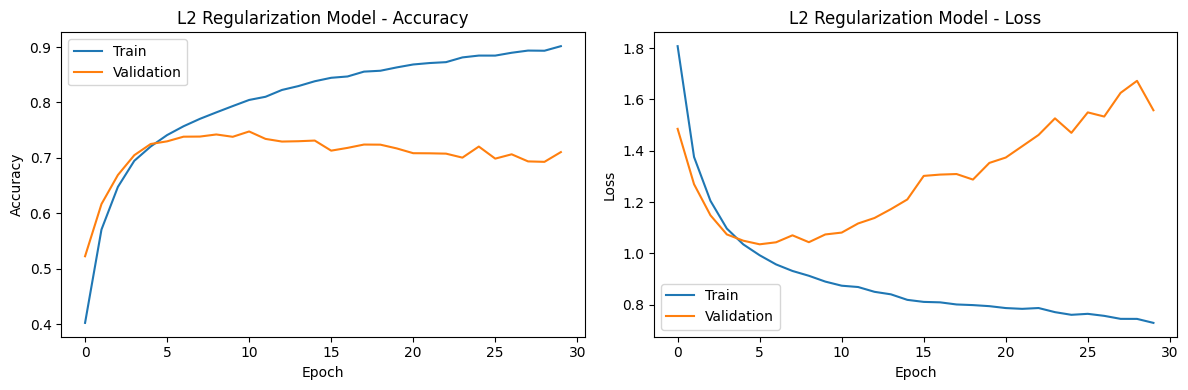

In [6]:
# ==============================
# PART B: Regularization (L2) applied to the SAME baseline architecture
# ==============================
l2_model = build_base_cnn(use_l2=True, use_dropout=False, l2_lambda=1e-3)
l2_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training L2-REGULARIZED model (same architecture as overfit baseline)...")
history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=30,
    validation_data=(x_val, y_val),
    batch_size=64,
    verbose=2
)

plot_history(history_l2, "L2 Regularization Model")

Training DROPOUT model (same architecture as overfit baseline)...
Epoch 1/30
704/704 - 16s - 23ms/step - accuracy: 0.4027 - loss: 1.6234 - val_accuracy: 0.5736 - val_loss: 1.1822
Epoch 2/30
704/704 - 7s - 10ms/step - accuracy: 0.5797 - loss: 1.1891 - val_accuracy: 0.6484 - val_loss: 0.9819
Epoch 3/30
704/704 - 7s - 10ms/step - accuracy: 0.6543 - loss: 0.9906 - val_accuracy: 0.7022 - val_loss: 0.8431
Epoch 4/30
704/704 - 7s - 10ms/step - accuracy: 0.6997 - loss: 0.8580 - val_accuracy: 0.7282 - val_loss: 0.7703
Epoch 5/30
704/704 - 7s - 10ms/step - accuracy: 0.7360 - loss: 0.7598 - val_accuracy: 0.7454 - val_loss: 0.7360
Epoch 6/30
704/704 - 7s - 10ms/step - accuracy: 0.7607 - loss: 0.6853 - val_accuracy: 0.7396 - val_loss: 0.7616
Epoch 7/30
704/704 - 7s - 10ms/step - accuracy: 0.7791 - loss: 0.6310 - val_accuracy: 0.7424 - val_loss: 0.7701
Epoch 8/30
704/704 - 7s - 10ms/step - accuracy: 0.7997 - loss: 0.5704 - val_accuracy: 0.7622 - val_loss: 0.7038
Epoch 9/30
704/704 - 7s - 10ms/step -

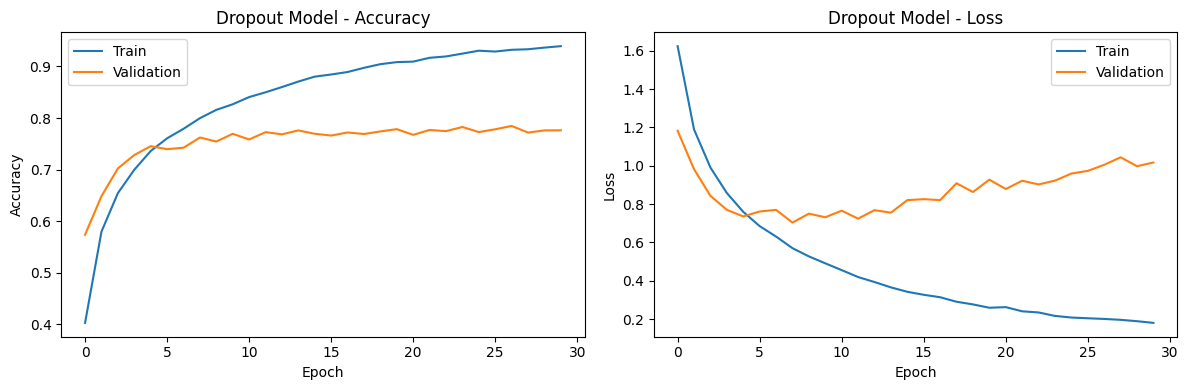

In [7]:
# ==============================
# PART C: Dropout applied to the SAME baseline architecture
# ==============================
dropout_model = build_base_cnn(use_l2=False, use_dropout=True, dropout_rates=(0.25, 0.25, 0.5))
dropout_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("Training DROPOUT model (same architecture as overfit baseline)...")
history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=30,
    validation_data=(x_val, y_val),
    batch_size=64,
    verbose=2
)

plot_history(history_dropout, "Dropout Model")

Training COMBINED (L2 + Dropout) model...
Epoch 1/30
704/704 - 18s - 26ms/step - accuracy: 0.3622 - loss: 1.9201 - val_accuracy: 0.4660 - val_loss: 1.5917
Epoch 2/30
704/704 - 7s - 10ms/step - accuracy: 0.5024 - loss: 1.5443 - val_accuracy: 0.5574 - val_loss: 1.3918
Epoch 3/30
704/704 - 7s - 10ms/step - accuracy: 0.5599 - loss: 1.4211 - val_accuracy: 0.6104 - val_loss: 1.2711
Epoch 4/30
704/704 - 7s - 10ms/step - accuracy: 0.6069 - loss: 1.3243 - val_accuracy: 0.6502 - val_loss: 1.1921
Epoch 5/30
704/704 - 7s - 10ms/step - accuracy: 0.6420 - loss: 1.2504 - val_accuracy: 0.6662 - val_loss: 1.1660
Epoch 6/30
704/704 - 7s - 10ms/step - accuracy: 0.6684 - loss: 1.1916 - val_accuracy: 0.6940 - val_loss: 1.1044
Epoch 7/30
704/704 - 7s - 10ms/step - accuracy: 0.6851 - loss: 1.1471 - val_accuracy: 0.7258 - val_loss: 1.0375
Epoch 8/30
704/704 - 7s - 10ms/step - accuracy: 0.6995 - loss: 1.1218 - val_accuracy: 0.7262 - val_loss: 1.0555
Epoch 9/30
704/704 - 7s - 10ms/step - accuracy: 0.7083 - loss

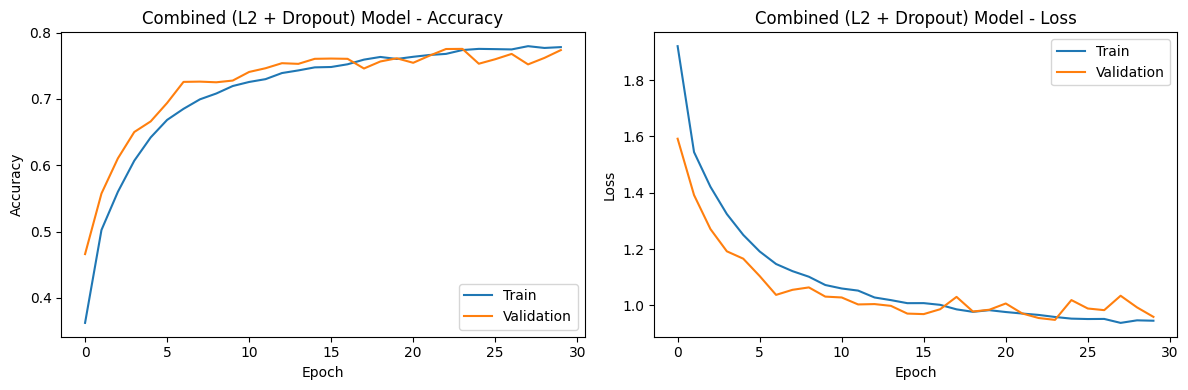

In [8]:
# ==============================
# PART D: Combined (L2 + Dropout) — SAME baseline architecture
# ==============================
combined_model = build_base_cnn(use_l2=True, use_dropout=True, l2_lambda=1e-3, dropout_rates=(0.25, 0.25, 0.5))
combined_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

print("Training COMBINED (L2 + Dropout) model...")
history_combined = combined_model.fit(
    x_train, y_train,
    epochs=30,
    validation_data=(x_val, y_val),
    batch_size=64,
    verbose=2
)

plot_history(history_combined, "Combined (L2 + Dropout) Model")

In [9]:
# ==============================
# Final Comparison + Performance Metrics (on held-out TEST set)
# ==============================
model_names, accuracies, f1_scores = [], [], []

evaluate_and_report(underfit_model, "Underfit", model_names, accuracies, f1_scores)
evaluate_and_report(overfit_model, "Overfit (baseline)", model_names, accuracies, f1_scores)
evaluate_and_report(l2_model, "L2 Regularized", model_names, accuracies, f1_scores)
evaluate_and_report(dropout_model, "Dropout", model_names, accuracies, f1_scores)
evaluate_and_report(combined_model, "Combined (L2+Dropout)", model_names, accuracies, f1_scores)

print("\nSummary Table:")
print(f"{'Model':<25}{'Test Acc':<12}{'Macro F1':<12}")
for n, a, f in zip(model_names, accuracies, f1_scores):
    print(f"{n:<25}{a:<12.4f}{f:<12.4f}")


Underfit — Test Loss: 1.2913 | Test Accuracy: 0.5462 | Macro F1: 0.5456
              precision    recall  f1-score   support

    airplane       0.59      0.59      0.59      1000
  automobile       0.69      0.66      0.67      1000
        bird       0.42      0.41      0.42      1000
         cat       0.38      0.49      0.43      1000
        deer       0.48      0.45      0.47      1000
         dog       0.48      0.42      0.45      1000
        frog       0.72      0.45      0.55      1000
       horse       0.64      0.59      0.62      1000
        ship       0.54      0.80      0.65      1000
       truck       0.65      0.59      0.62      1000

    accuracy                           0.55     10000
   macro avg       0.56      0.55      0.55     10000
weighted avg       0.56      0.55      0.55     10000


Overfit (baseline) — Test Loss: 2.1949 | Test Accuracy: 0.7251 | Macro F1: 0.7252
              precision    recall  f1-score   support

    airplane       0.77      0

/tmp/ipykernel_1423/1903308737.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(model_names, rotation=20, ha='right')
/tmp/ipykernel_1423/1903308737.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=20, ha='right')


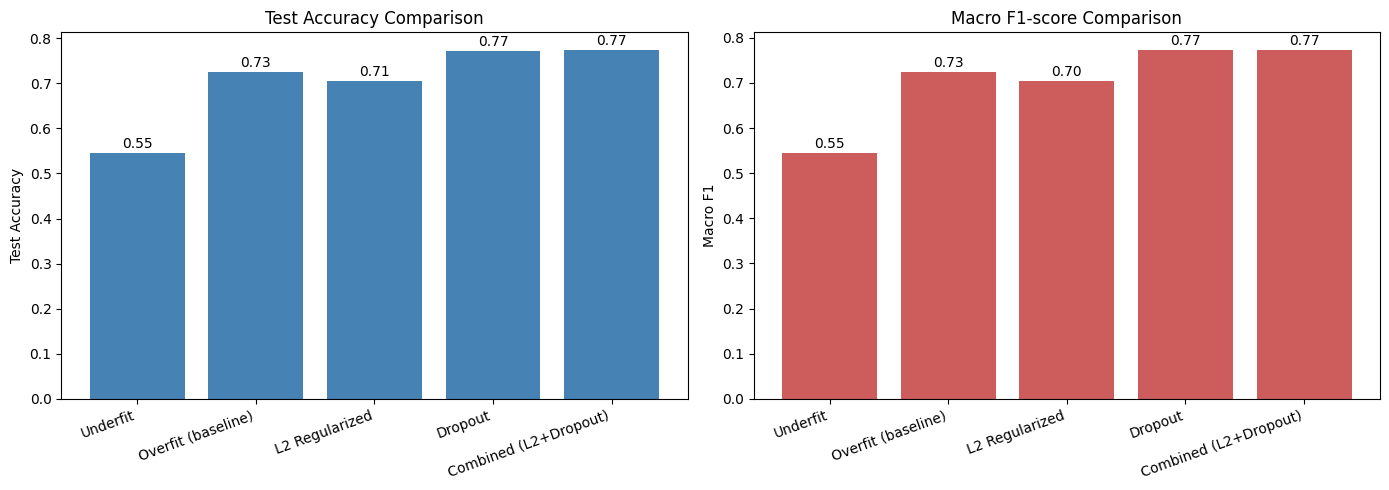

In [10]:
# ==============================
# Comparison Charts: Accuracy and F1 across all 5 scenarios
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].bar(model_names, accuracies, color='steelblue')
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_xticklabels(model_names, rotation=20, ha='right')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha='center')

axes[1].bar(model_names, f1_scores, color='indianred')
axes[1].set_title("Macro F1-score Comparison")
axes[1].set_ylabel("Macro F1")
axes[1].set_xticklabels(model_names, rotation=20, ha='right')
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# Train/Validation gap: quick numeric overfitting check
# (final-epoch train acc minus val acc; large gap => overfitting)
# ==============================
def final_gap(history, name):
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"{name:<25} Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  Gap: {train_acc - val_acc:.4f}")

final_gap(history_underfit, "Underfit")
final_gap(history_overfit, "Overfit (baseline)")
final_gap(history_l2, "L2 Regularized")
final_gap(history_dropout, "Dropout")
final_gap(history_combined, "Combined")